# Predicing the precursor charge with macine learning

In [41]:
import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

In [42]:
import re

AA_BASIC = set("KRH")
AA_ACIDIC = set("DE")

def extract_features(row):
    seq = row["peptide_sequence"]

    # remove modifications
    clean_seq = re.sub(r"\[.*?\]", "", seq)

    intensities = np.asarray(row["intensities_raw"])

    log_int = np.log1p(intensities)

    ions = row["matched_ions"]

    b_nums = []
    y_nums = []

    for ion in ions:
        if ion.startswith("b"):
            b_nums.append(int(ion[1:]))
        elif ion.startswith("y"):
            y_nums.append(int(ion[1:]))


    return {
        "length": len(clean_seq),
        "n_KRH": sum(aa in AA_BASIC for aa in clean_seq),
        "n_DE": sum(aa in AA_ACIDIC for aa in clean_seq),

        "n_b": len(b_nums),
        "n_y": len(y_nums),
        "max_b": max(b_nums) if b_nums else 0,
        "max_y": max(y_nums) if y_nums else 0,

        "int_mean": log_int.mean(),
        "int_std": log_int.std(),
        "int_max": log_int.max(),
        "int_median": np.median(log_int),
        "int_sum": log_int.sum(),
    }

In [43]:
FEATURES_NAMES = [
    "pep sequ length",           # peptide sequence length
    "n basic AAs",           # count of basic amino acids (K, R, H)
    "n acidic AAs",            # count of acidic amino acids (D, E)
    "n b ions matched",             # number of b ions matched
    "n y ions matched",             # number of y ions matched
    "highest b ion number",           # maximum b ion number
    "highest y ion number",           # maximum y ion number
    "mean log intensity",        # mean log-transformed intensity
    "std of log intensity",         # std dev of log-transformed intensity
    "max log intensity",         # max log-transformed intensity
    "median log intensity",      # median log-transformed intensity
    "sum log intensity",         # sum of log-transformed intensities
]

In [44]:
df = pd.read_parquet("data_for_student.parquet")
meta = pd.read_parquet("metadata_for_student.parquet")
merged = df.merge(meta, on=["raw_file", "scan_number"], how="inner")


known = merged[merged.precursor_charge.notna()].copy()
known = known[known.precursor_charge != 6].copy()

X = pd.DataFrame(
    known.apply(extract_features, axis=1).tolist()
)

y = known["precursor_charge"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

In [45]:
classes = np.sort(y.unique())

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y
)

class_weight = dict(zip(classes, weights))

In [46]:
clf = HistGradientBoostingClassifier(
    max_depth=8,
    learning_rate=0.05,
    max_iter=300,
    random_state=42
)

clf.fit(X_train, y_train)

pred = clf.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        11
           2       1.00      0.99      0.99     42763
           3       0.98      0.99      0.98     25030
           4       0.92      0.85      0.88      2188
           5       0.18      0.42      0.25        43

    accuracy                           0.99     70035
   macro avg       0.61      0.65      0.62     70035
weighted avg       0.99      0.99      0.99     70035



/tmp/ipykernel_32285/874448093.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(importances.T, vert=False, labels=labels)


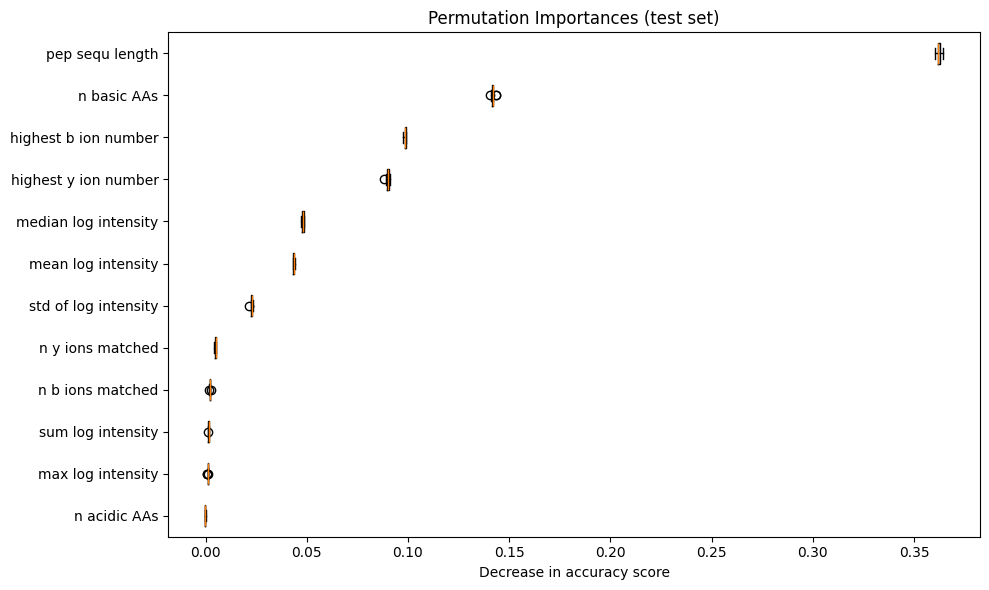

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance



# 3. Calculate Permutation Importance
result = permutation_importance(
    clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# 4. Sort indices based on importance mean
sorted_importances_idx = result.importances_mean.argsort()
importances = result.importances[sorted_importances_idx]
labels = np.array(FEATURES_NAMES)[sorted_importances_idx]

# 5. Plot the results
plt.figure(figsize=(10, 6))
plt.boxplot(importances.T, vert=False, labels=labels)
plt.title("Permutation Importances (test set)")
plt.xlabel("Decrease in accuracy score")
plt.tight_layout()
plt.show()

### Cat Boost because gradient boosting and nya nya

do 
```python
$ uv pip install catboost
```
to install required libraries

In [51]:


from catboost import CatBoostClassifier

clf = CatBoostClassifier(
    depth=8,
    iterations=500,
    learning_rate=0.05,
    loss_function="MultiClass",
    auto_class_weights="Balanced",
    verbose=100
)

clf.fit(X_train, y_train)

pred = clf.predict(X_test)

print(classification_report(y_test, pred))

0:	learn: 1.4999683	total: 118ms	remaining: 59s
100:	learn: 0.2117983	total: 8.31s	remaining: 32.8s
200:	learn: 0.1272004	total: 16.8s	remaining: 25s
300:	learn: 0.0842581	total: 25.2s	remaining: 16.7s
400:	learn: 0.0609293	total: 33.9s	remaining: 8.37s
499:	learn: 0.0484511	total: 42.3s	remaining: 0us
              precision    recall  f1-score   support

           1       0.08      0.91      0.15        11
           2       1.00      0.99      0.99     42763
           3       0.99      0.97      0.98     25030
           4       0.77      0.97      0.86      2188
           5       0.44      0.67      0.53        43

    accuracy                           0.98     70035
   macro avg       0.66      0.90      0.70     70035
weighted avg       0.99      0.98      0.98     70035



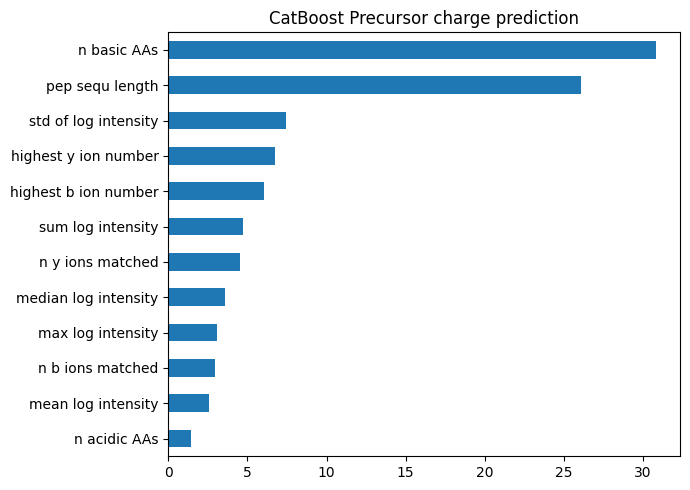

In [52]:
import matplotlib.pyplot as plt


# Look at this graph!
imp = pd.Series(clf.feature_importances_, index=FEATURES_NAMES).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
imp.plot.barh(ax=ax); ax.set_title("CatBoost Precursor charge prediction")
plt.tight_layout(); plt.show()

In [54]:
#clf.booster_.save_model("precursor-catboost.model")
import joblib

# Save the model
joblib.dump(clf, 'precursor-catboost.pkl')

['precursor-catboost.pkl']